In [1]:
import pandas as pd
import glob
import matplotlib.pyplot as plt
# Food consumption score - fcs
# Reduced Coping Strategies Index (rCSI)

In [2]:
inputfldr = ''
data_fn = f'{inputfldr}*.csv'
data_file = glob.glob(data_fn)[0]

In [3]:
df = pd.read_csv(data_file,header=1, index_col=0)
df['#date'] = pd.to_datetime(df['#date'])
column_name = '#indicator+name'
df = df[(df[column_name] == 'fcs') | (df[column_name] == 'rcsi')]
df = df.dropna()

In [4]:
df_fcs = df[df["#indicator+name"] == "fcs"].rename(columns={"#indicator+prevalence": "fcs_prevalence"}).drop("#indicator+name", axis=1)
df_rcsi = df[df["#indicator+name"] == "rcsi"].rename(columns={"#indicator+prevalence": "rcsi_prevalence"}).drop("#indicator+name", axis=1)

df_merged = pd.merge(df_fcs, df_rcsi, 
                      on=["#country+name", "#adm1+name", "#date", "#data+type"], 
                      how="outer")



In [5]:
df_merged["#adm1+name"].unique()

array(['Abia', 'Abuja', 'Adamawa', 'Akwa Ibom', 'Bauchi', 'Benue',
       'Borno', 'Cross River', 'Edo', 'Enugu', 'Gombe', 'Jigawa',
       'Kaduna', 'Kano', 'Katsina', 'Kebbi', 'Kogi', 'Kwara', 'Lagos',
       'Nassarawa', 'Niger', 'Ogun', 'Plateau', 'Rivers', 'Sokoto',
       'Taraba', 'Yobe', 'Zamfara'], dtype=object)

In [6]:
df_filtered = df_merged[df_merged["#adm1+name"].isin(["Kano", "Lagos","Kebbi","Ogun"])]
df_filtered.set_index("#date", inplace=True)

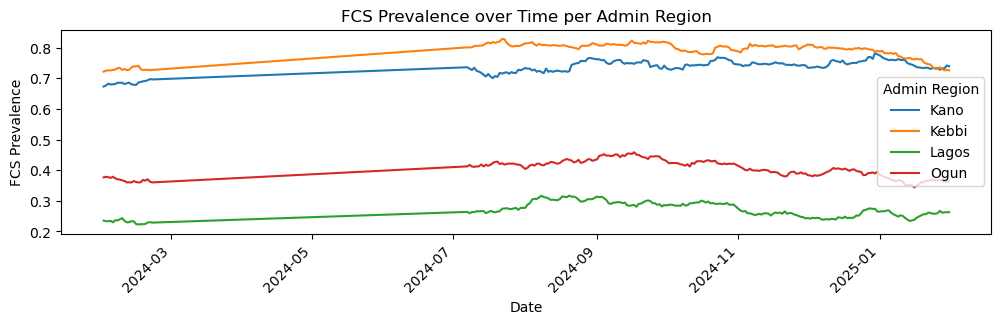

In [7]:
# df_filtered.fcs_prevalence.plot()

# Group by 'adm_region' and 'index' date, and calculate the mean (or sum) of 'fcs_prevalence'
region_time_fcs = df_filtered.groupby([df_filtered.index, '#adm1+name'])['fcs_prevalence'].mean().unstack()

# Plot the results
region_time_fcs.plot(figsize=(12, 3))

# Add labels and title
plt.xlabel('Date')
plt.ylabel('FCS Prevalence')
plt.title('FCS Prevalence over Time per Admin Region')
plt.legend(title='Admin Region')
plt.xticks(rotation=45)
plt.show()

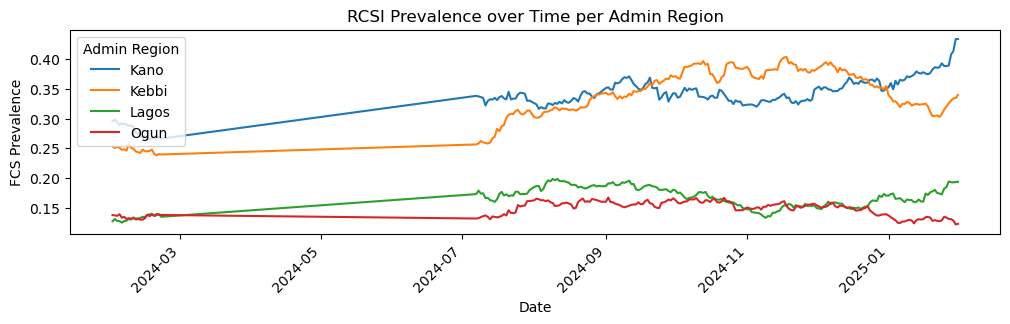

In [8]:

# Group by 'adm_region' and 'index' date, and calculate the mean (or sum) of 'fcs_prevalence'
region_time_fcs = df_filtered.groupby([df_filtered.index, '#adm1+name'])['rcsi_prevalence'].mean().unstack()

# Plot the results
region_time_fcs.plot(figsize=(12, 3))

# Add labels and title
plt.xlabel('Date')
plt.ylabel('FCS Prevalence')
plt.title('RCSI Prevalence over Time per Admin Region')
plt.legend(title='Admin Region')
plt.xticks(rotation=45)
plt.show()

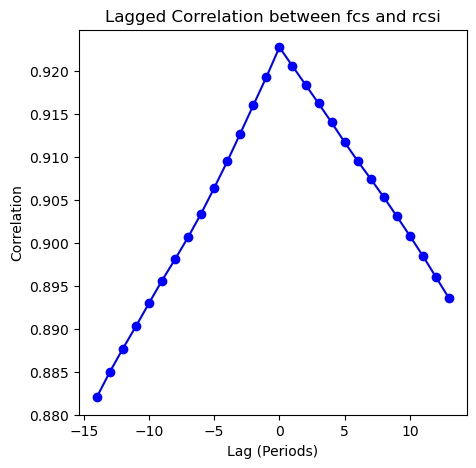

In [9]:
rcsi = df_filtered['rcsi_prevalence']
fcs = df_filtered['fcs_prevalence']
column1= 'rcsi_prevalence'
column2='fcs_prevalence'

# Calculate the correlation between the two columns
# correlation = rcsi.corr(fcs)
# correlation

# Define the lag range (e.g., 1 to 10 lags)
lags = range(-14, 14)

# Create a list to store correlation values for each lag
lagged_correlations = []

# Loop over the lags and calculate the correlation between the columns
for lag in lags:
    # Create lagged version of column2
    column2_lagged = df_filtered[column2].shift(lag)
    
    # Calculate the correlation between 'column1' and the lagged 'column2'
    corr = df_filtered[column1].corr(column2_lagged)
    
    # Append the result to the list
    lagged_correlations.append(corr)

# Plot the lagged correlation values
plt.figure(figsize=(5, 5))
plt.plot(lags, lagged_correlations, marker='o', linestyle='-', color='b')

# Add labels and title
plt.xlabel('Lag (Periods)')
plt.ylabel('Correlation')
plt.title('Lagged Correlation between fcs and rcsi')

# Display the plot
plt.show()

In [10]:
df_filtered

,#country+name,#adm1+name,#meta+adminlevel_x,#data+type,#population_x,fcs_prevalence,#meta+adminlevel_y,#population_y,rcsi_prevalence
#date,,,,,,,,,
2024-02-01,Nigeria,Kano,subnational,SURVEY,10054265,0.673149,subnational,4414279,0.295543
2024-02-02,Nigeria,Kano,subnational,SURVEY,10107124,0.676688,subnational,4455144,0.298279
2024-02-03,Nigeria,Kano,subnational,SURVEY,10193485,0.682470,subnational,4386288,0.293669
2024-02-04,Nigeria,Kano,subnational,SURVEY,10150947,0.679622,subnational,4319598,0.289204
2024-02-05,Nigeria,Kano,subnational,SURVEY,10164942,0.680559,subnational,4356297,0.291661
...,...,...,...,...,...,...,...,...,...
2025-01-27,Nigeria,Ogun,subnational,SURVEY,1994463,0.368745,subnational,708177,0.130931
2025-01-28,Nigeria,Ogun,subnational,SURVEY,1975164,0.365177,subnational,705981,0.130525
2025-01-29,Nigeria,Ogun,subnational,SURVEY,1955454,0.361533,subnational,693482,0.128214


In [18]:
df_filtered = df_filtered[df_filtered["#adm1+name"].isin(["Kano"])]
df_filtered.index = pd.to_datetime(df_filtered.index)


start_date = pd.to_datetime('2025-01-06')
start_date_train = start_date - pd.Timedelta(days=100)
end_date = start_date + pd.Timedelta(days=7)

filtered_df_train = df_filtered[(df_filtered.index >= start_date_train) & (df_filtered.index < start_date)]
filtered_df_test = df_filtered[(df_filtered.index >= start_date) & (df_filtered.index < end_date)]

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet

# Assuming df_filtered is already loaded and 'fcs_prevalence' is the target column

# Prepare the data for Prophet
filtered_df_train = filtered_df_train.reset_index().dropna()
filtered_df_train = filtered_df_train.rename(columns={'#date': 'ds', 'fcs_prevalence': 'y'})
filtered_df_test = filtered_df_test.reset_index().dropna()
filtered_df_test = filtered_df_test.rename(columns={'#date': 'ds', 'fcs_prevalence': 'y'})

# Ensure 'ds' is of datetime type
# df_prophet['ds'] = pd.to_datetime(df_prophet['ds'])

# Initialize the Prophet model
model = Prophet()

# Fit the model to the data
model.fit(filtered_df_train)

# Make a dataframe to hold predictions for the next 365 days (adjust based on your forecast horizon)

# Make predictions
forecast = model.predict(filtered_df_test)

# model.plot_components(forecast)

03:01:33 - cmdstanpy - INFO - Chain [1] start processing
03:01:34 - cmdstanpy - INFO - Chain [1] done processing


In [17]:
import numpy as np

predicted = forecast.yhat
actual = filtered_df_test.y

# Calculate absolute errors
absolute_errors = np.abs(actual - predicted)

# Calculate Mean Absolute Error
mae = np.mean(absolute_errors)
mae

0.016814127476061386

In [14]:
forecast.set_index("ds", inplace=True)

In [15]:
filtered_df_test.set_index("ds", inplace=True)

<Axes: xlabel='ds'>

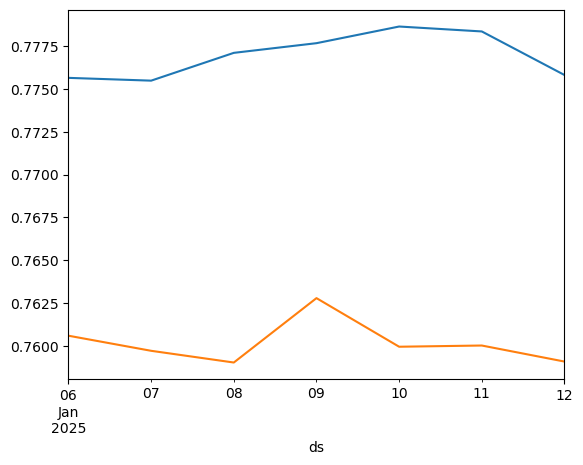

In [16]:
forecast.yhat.plot()
filtered_df_test.y.plot()